### Setup

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import torch
import os, shutil, pathlib
from PIL import Image

In [3]:
# Quick health check to prove it works:
print("Is PyTorch utilizing the GPU?:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0))

Is PyTorch utilizing the GPU?: True
Device Name: NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
model_name = "catsvsdogs30epoch.keras"
batch_size = 128
image_size = (512, 512)

### Load Datasets

In [5]:
dataset_dir = "Datasets"
original_dir = pathlib.Path(f"{dataset_dir}/train")
new_base_dir = pathlib.Path(f"{dataset_dir}/dogs_vs_cats_small")

In [6]:
def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)

In [7]:
#make_subset("sub_train", start_index=0, end_index=7500)
#make_subset("sub_validation", start_index=7500, end_index=10000)
#make_subset("sub_test", start_index=10000, end_index=12500)

### Modelling

In [8]:
inputs = keras.Input(shape=(512, 512, 3))
x = keras.layers.Rescaling(1.0 / 255)(inputs)
x = keras.layers.Conv2D(filters=64, strides=2, kernel_size=3, activation="relu")(x)
x = keras.layers.Conv2D(filters=128, strides=2, kernel_size=3, activation="relu")(x)
x = keras.layers.Conv2D(filters=256, strides=2, kernel_size=3, activation="relu")(x)
x = keras.layers.Conv2D(filters=512, strides=2, kernel_size=3, activation="relu")(x)
x = keras.layers.Conv2D(filters=512, strides=2, kernel_size=3, activation="relu")(x)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 255, 255, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 127, 127, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 31, 31, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,108,161 (15.67 MB)

 Trainable params: 4,108,161 (15.67 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

### Data Preprocessing

In [10]:
dataset_dir = "Datasets"
original_dir = pathlib.Path(f"{dataset_dir}/train")
new_base_dir = pathlib.Path(f"{dataset_dir}/dogs_vs_cats_small")

In [11]:
train_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "sub_train", image_size=image_size, batch_size=batch_size)
validation_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "sub_validation", image_size=image_size, batch_size=batch_size)
test_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "sub_test", image_size=image_size, batch_size=batch_size)

Found 15000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [12]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break


data batch shape: (128, 512, 512, 3)
labels batch shape: (128,)


In [13]:
data_augmentation_layers = [
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.2),
]

def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
        return images, targets

augmented_train_dataset = train_dataset.map(data_augmentation, num_parallel_calls=8)
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

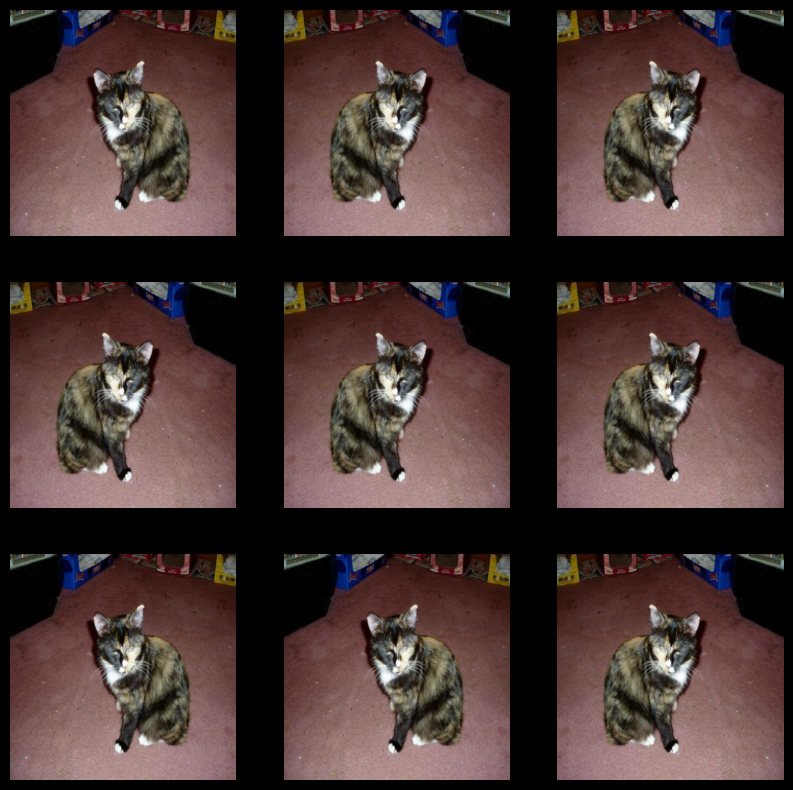

In [14]:
plt.figure(figsize=(10, 10))
for image_batch, _ in train_dataset.take(1):
    image = image_batch[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image, _ = data_augmentation(image, None)
        augmented_image = keras.ops.convert_to_numpy(augmented_image)
        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")

### Model Training & Evaluation

In [ ]:
callbacks = [keras.callbacks.ModelCheckpoint(filepath=model_name, save_best_only=True, monitor="val_loss"), keras.callbacks.EarlyStopping(monitor="val_loss", patience=3)]
history = model.fit(train_dataset, epochs=30, validation_data=validation_dataset, callbacks=callbacks)

Epoch 1/30


In [ ]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_model = keras.models.load_model(model_name)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test loss: {test_loss:.3f}")

### Submission

In [ ]:
dataset_dir = "Datasets"
submission_dir = pathlib.Path(f"{dataset_dir}/test")

In [ ]:
image_paths = sorted(submission_dir.glob("*.jpg"), key=lambda x: int(x.stem))
print(f"Found {len(image_paths)} images")
images = []
for path in image_paths:
    img = Image.open(path).convert("RGB")
    img = img.resize(image_size)
    images.append(np.array(img))
sub_images = np.array(images)
print("Dataset shape:", sub_images.shape)

In [ ]:
for i in range(3):
    print(i, image_paths[i])
    plt.imshow(sub_images[i].astype("uint8"))
    plt.title(image_paths[i].name)
    plt.axis("off")
    plt.show()

In [ ]:
test_model = keras.models.load_model(model_name)
test_model.summary()

In [ ]:
predictions = test_model.predict(sub_images)

In [ ]:
preds = [i[0] for i in predictions.tolist()]
submission = {"id": list(range(1, 12501)), "label": preds}
df = pd.DataFrame(submission)
df

In [ ]:
df.to_csv("submission_cnn.csv", index=False)

In [1]:
# 